# **K-Means Clustering for Color Quantization**

## **Introduction and Motivation**

In this lecture, we explore a **creative application of unsupervised learning**:  
**color quantization using K-Means clustering**.

Unlike supervised learning, where we optimize for prediction accuracy, unsupervised learning allows us to:
- Discover patterns
- Transform data
- Apply algorithms in flexible and innovative ways

Color quantization is a perfect example of this flexibility.



### **What is Color Quantization?**

Color quantization is the process of:
> **Reducing the number of distinct colors in an image**  while preserving its overall appearance as much as possible.

Using K-Means:
- Original image → many colors
- Quantized image → only K colors


### **Intuition**

- Similar colors (e.g., shades of blue) → grouped together  
- Each group → replaced by a single representative color  

Example:
- Many shades of orange → one “average orange”
- Many shades of blue → one “average blue”


### **Why is This Useful?**

- Image compression (smaller storage)
- Faster rendering
- Simplified visualization
- Artistic effects

<br>

## **How Computers Represent Images**

To understand this application, we must first understand how images are stored.

### **Grayscale Images**
- Represented as a **2D array**
- Each pixel has a value:
  - 0 → white  
  - 1 (or 255) → black  
  - Values in between → shades of gray





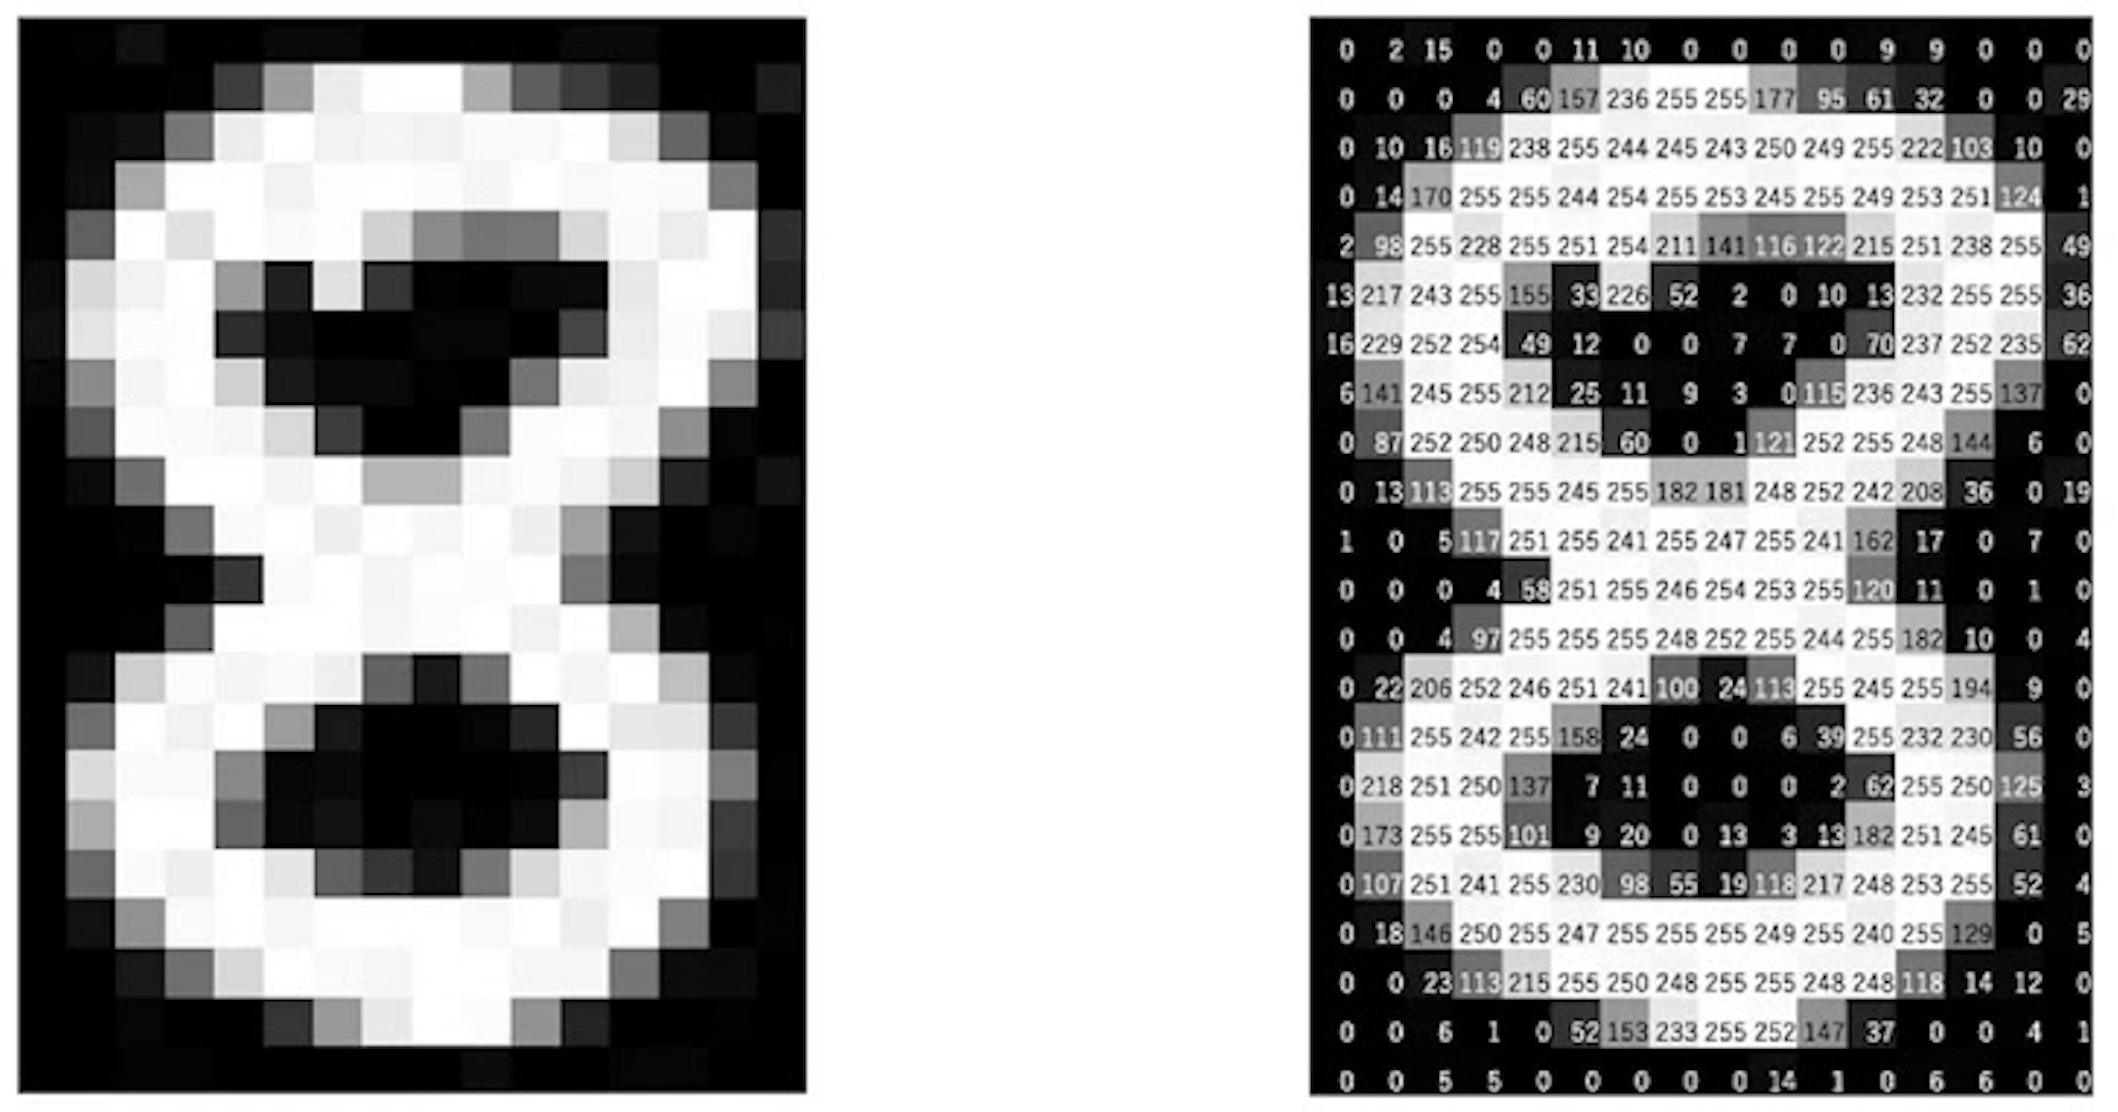

### **Color Images (RGB Representation)**

Color images use **three channels**:
- Red (R)
- Green (G)
- Blue (B)

Each pixel is represented as:
(R, G, B)

For example:
- (213, 111, 56) represents a specific color

Thus, a color image is a **3D array**:
Height × Width × 3

Each channel is essentially a grayscale image.

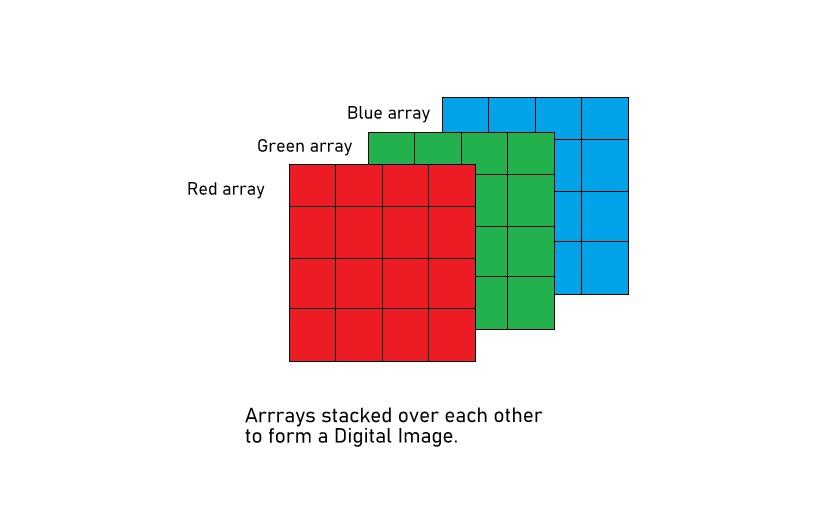

## **Key Idea: Pixels as Data Points**

Each pixel can be viewed as a **data point with 3 features**:
- Feature 1: Red intensity
- Feature 2: Green intensity
- Feature 3: Blue intensity

To apply machine learning:
- We **reshape the image**
- Convert it into a dataset:

X = [
  [R, G, B],
  [R, G, B],
  ...
]

Each row = one pixel  
Each column = one feature (RGB)

## **Applying K-Means Clustering**

- **Step 1: Choose K**
  - K = number of colors we want in the final image

- **Step 2: Cluster Pixels**
  - Apply K-Means on RGB data
  - Pixels are grouped based on **color similarity**

- **Step 3: Use Cluster Centers**
  - Each cluster has a centroid:(R̄, Ḡ, B̄)
  - This represents an **average color**

- **Step 4: Reassign Colors**
  - Replace each pixel’s original color
  - With its cluster center color

# **K Means Color Quantization sklearn**

In [146]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

In [147]:
image_as_array = mpimg.imread('parr.jpeg')

In [148]:
print(image_as_array) # RGB CODES FOR EACH PIXEL

[[[152 174 162]
  [153 175 163]
  [154 176 164]
  ...
  [111 100  94]
  [116 105  99]
  [124 111 105]]

 [[153 174 165]
  [153 174 165]
  [154 175 166]
  ...
  [111 100  94]
  [116 105  99]
  [124 111 105]]

 [[153 174 165]
  [154 175 166]
  [155 176 167]
  ...
  [110  99  93]
  [116 105  99]
  [124 111 105]]

 ...

 [[165 157 144]
  [156 150 136]
  [146 140 128]
  ...
  [  4  39  59]
  [ 17  55  94]
  [ 13  59 119]]

 [[165 157 144]
  [157 149 136]
  [146 140 128]
  ...
  [  0  26  39]
  [ 10  40  74]
  [ 14  51 106]]

 [[166 156 144]
  [157 149 136]
  [147 139 128]
  ...
  [  7  25  35]
  [  7  30  61]
  [ 11  43  94]]]


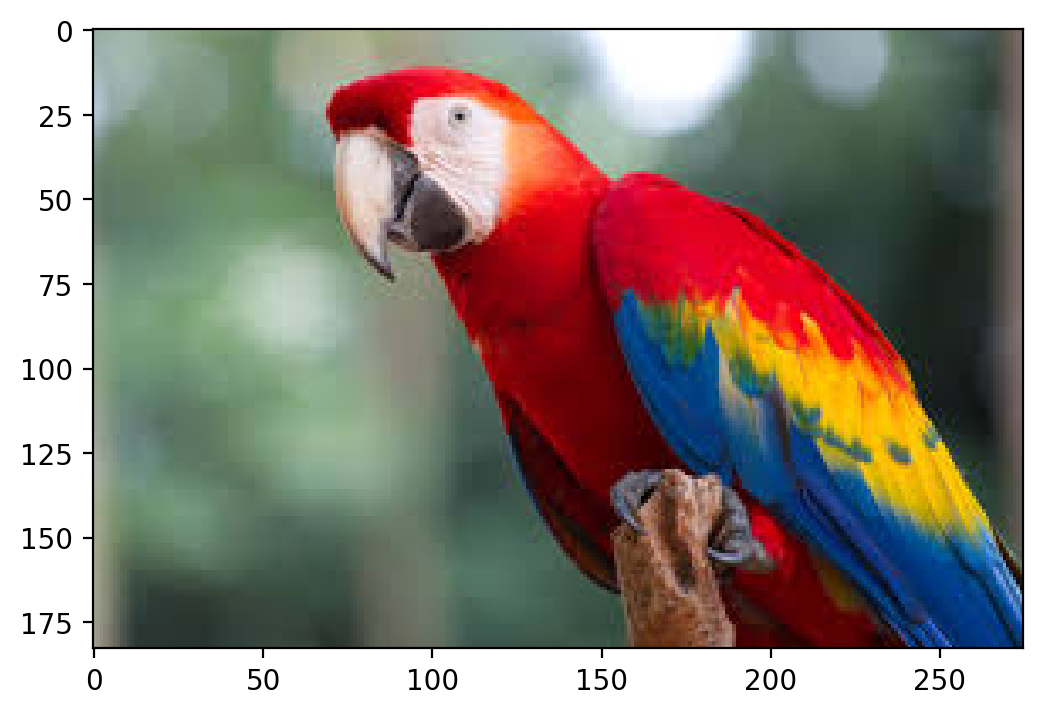

In [149]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(image_as_array)

## **Using Kmeans to Quantize Colors**

Quantizing colors means we'll reduce the number of unique colors here to K unique colors. Let's try just 6 colors!

In [150]:
image_as_array.shape
# (h,w,3 color channels)

(183, 275, 3)

### **Convert from 3d to 2d**

Kmeans is designed to train on 2D data (data rows and feature columns), so we can reshape the above strip by using (h,w,c) ---> (h * w,c)

In [151]:
(h,w,c) = image_as_array.shape

In [152]:
image_as_array2d = image_as_array.reshape(h*w,c)

In [153]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=10)

In [154]:
labels = model.fit_predict(image_as_array2d)

In [155]:
labels

array([2, 2, 2, ..., 3, 3, 7], dtype=int32)

In [156]:
# THESE ARE THE 6 RGB COLOR CODES!
model.cluster_centers_

array([[123.4657876 , 144.96151105, 121.59491566],
       [109.58373086,   5.17474266,   9.24278182],
       [159.52487854, 175.24040878, 159.85156643],
       [ 37.39420154,  28.55365911,  27.08674304],
       [235.27192575, 162.28677494,  23.41531323],
       [232.84975479, 227.9674543 , 229.60855996],
       [ 61.3173879 ,  74.71363399,  64.77124609],
       [ 10.28001319,  61.98548813, 121.23680739],
       [218.16493622,  13.49866508,  33.38000593],
       [ 95.54883216, 112.15556763,  95.13992395]])

In [157]:
rgb_codes = model.cluster_centers_.round(0).astype(int)

In [158]:
rgb_codes

array([[123, 145, 122],
       [110,   5,   9],
       [160, 175, 160],
       [ 37,  29,  27],
       [235, 162,  23],
       [233, 228, 230],
       [ 61,  75,  65],
       [ 10,  62, 121],
       [218,  13,  33],
       [ 96, 112,  95]])

In [159]:
quantized_image = np.reshape(rgb_codes[labels], (h, w, c))

In [160]:
quantized_image

array([[[160, 175, 160],
        [160, 175, 160],
        [160, 175, 160],
        ...,
        [ 96, 112,  95],
        [ 96, 112,  95],
        [ 96, 112,  95]],

       [[160, 175, 160],
        [160, 175, 160],
        [160, 175, 160],
        ...,
        [ 96, 112,  95],
        [ 96, 112,  95],
        [ 96, 112,  95]],

       [[160, 175, 160],
        [160, 175, 160],
        [160, 175, 160],
        ...,
        [ 96, 112,  95],
        [ 96, 112,  95],
        [ 96, 112,  95]],

       ...,

       [[160, 175, 160],
        [160, 175, 160],
        [123, 145, 122],
        ...,
        [ 37,  29,  27],
        [ 10,  62, 121],
        [ 10,  62, 121]],

       [[160, 175, 160],
        [160, 175, 160],
        [123, 145, 122],
        ...,
        [ 37,  29,  27],
        [ 10,  62, 121],
        [ 10,  62, 121]],

       [[160, 175, 160],
        [160, 175, 160],
        [123, 145, 122],
        ...,
        [ 37,  29,  27],
        [ 37,  29,  27],
        [ 10,  62, 121]]

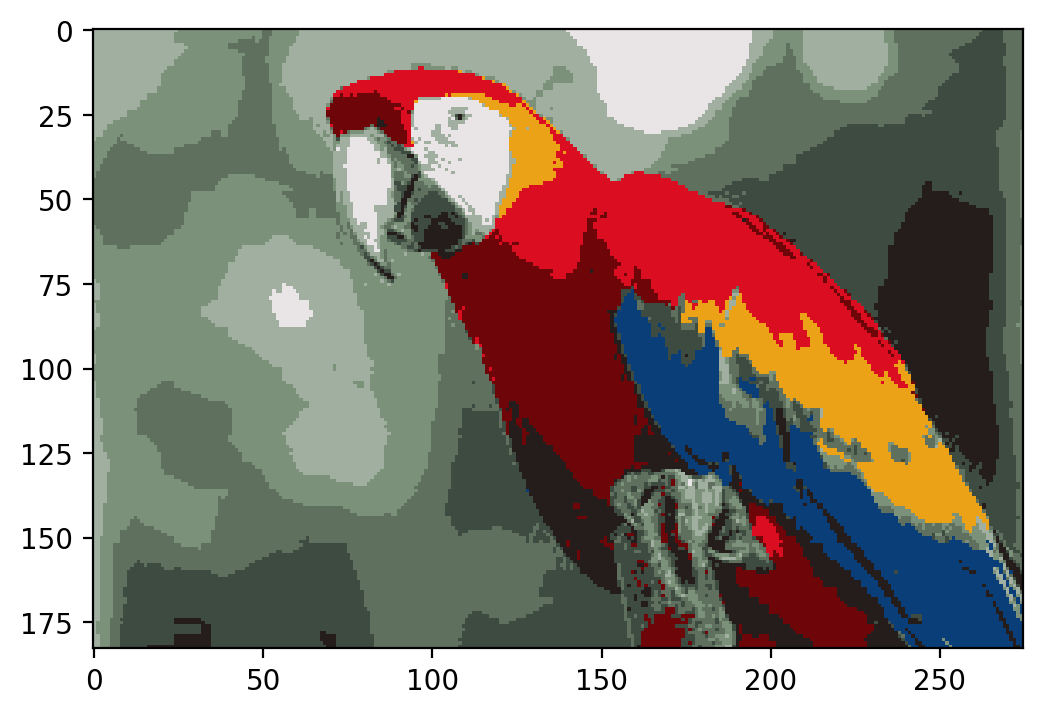

In [161]:
plt.figure(figsize=(6,6),dpi=200)
plt.imshow(quantized_image)

### **Key Takeaways**

- Images can be treated as **datasets**
- Pixels become **feature vectors (RGB)**
- K-Means clusters similar colors
- Cluster centers define the **reduced color palette**
- This process is called **color quantization**